# Importo bliblotecas

In [ ]:
# Biblioteca
import os
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import confusion_matrix, precision_recall_curve
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score, roc_curve, average_precision_score
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv("/content/drive/MyDrive/DCDDyAAG15/creditcard.csv")


Mounted at /content/drive


# EDA

In [ ]:
df = df.drop_duplicates()
df = df.drop("Time", axis=1)

positivos = np.sum(df["Class"])
total = np.size(df["Class"])
print('Porcentaje de positivos: {:.2f}%'.format(100 * positivos / total))

#Defino el importe por el que dividirá el dataset
min = 10

#SEPARO EN MAYORES A MIN Y MENORS O IGUALES A MIN
df_mayor = df.where(df["Amount"] > min).dropna()
df_menor = df.where(df["Amount"] <= min).dropna()

#SACO LOS QUE TIENEN AMOUNT = 0
df_menor = df_menor.where(df["Amount"] > 0).dropna()

Porcentaje de positivos: 0.17%


In [ ]:
rnd_state = 18

X_mayor = df_mayor.drop('Class', axis=1)
y_mayor = df_mayor['Class']

X_train_mayor, X_test_mayor, y_train_mayor, y_test_mayor = train_test_split(X_mayor, y_mayor, test_size=0.3, random_state=rnd_state)#, stratify=y_mayor)

ratio_mayor = len(y_train_mayor[y_train_mayor == 0]) / len(y_train_mayor[y_train_mayor == 1])

X_menor = df_menor.drop('Class', axis=1)
y_menor = df_menor['Class']

X_train_menor, X_test_menor, y_train_menor, y_test_menor = train_test_split(X_menor, y_menor, test_size=0.3, random_state=rnd_state)#, stratify=y_menor)

ratio_menor = len(y_train_menor[y_train_menor == 0]) / len(y_train_menor[y_train_menor == 1])

positivos = np.sum(df_mayor["Class"])
total = np.size(df_mayor["Class"])
print('Porcentaje de positivos DF MAYOR: {:.2f}%'.format(100 * positivos / total))

positivos = np.sum(df_menor["Class"])
total = np.size(df_menor["Class"])
print('Porcentaje de positivos DF MENOR: {:.2f}%'.format(100 * positivos / total))

Porcentaje de positivos DF MAYOR: 0.13%
Porcentaje de positivos DF MENOR: 0.22%


# Función para armar el reporte

In [ ]:
def report(X_train, y_train, X_test, y_test, model=None, type="", model_name=""):
    # Predicciones
    y_hat = model.predict(X_test)

    # Métricas
    cm = confusion_matrix(y_test, y_hat)
    accuracy = round(accuracy_score(y_test, y_hat), 4)
    error_rate = round(1 - accuracy, 4)
    precision = round(precision_score(y_test, y_hat), 2)
    recall = round(recall_score(y_test, y_hat), 2)
    f1score = round(f1_score(y_test, y_hat), 2)
    roc_auc = roc_auc_score(y_test, y_hat)
    auprc = average_precision_score(y_test, y_hat)

    cm_labeled = pd.DataFrame(cm,
                              index=['Actual : negativos', 'Actual : positivos'],
                              columns=['Predicción : negativos', 'Predicción : positivos'])

    # Curva ROC
    fpr, tpr, _ = roc_curve(y_test, y_hat)
    plt.figure(figsize=(6,4))
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('Tasa de Falsos Positivos (FPR)')
    plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
    plt.title(f'Curva ROC - {model_name} ' + type)
    plt.legend(loc='lower right')

    precision, recall, _ = precision_recall_curve(y_test, y_hat)
    plt.figure(figsize=(6,4))
    plt.plot(recall, precision, label=f"{model_name} (AP = {auprc:.3f})")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision-Recall Curve")
    plt.legend()
    plt.show()

    # Reporte
    print("-----------------------------------------")
    print("Dataset " + type)
    print('Tamaño train: {}'.format(X_train.shape[0]))
    print('Tamaño test: {}'.format(X_test.shape[0]))
    print('Porcentaje de positivos: {:.2f}%'.format(100 * np.sum(y_train) / np.size(y_train)))
    print("-----------------------------------------")
    print("Resultados " + type)
    #print('Accuracy  = {}'.format(accuracy))
    print('Error_rate  = {}'.format(error_rate))
    print('Precision = {}'.format(precision))
    print('Recall    = {}'.format(recall))
    print('f1_score  = {}'.format(f1score))
    print('roc_auc  = {:.2f}'.format(roc_auc))
    print('auprc  = {:.2f}'.format(auprc))
    print("-----------------------------------------")

    return cm_labeled

# XGBoost Tuned

In [ ]:
%pip install xgboost
from xgboost import XGBClassifier

## Fit del modelo con GridSearch

In [ ]:
# Grid de hiperparámetros para XGBoost
param_grid_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

# Instanciamos el clasificador base
xgb_mayor = XGBClassifier(
    random_state=rnd_state,
    use_label_encoder=False,
    eval_metric='logloss',
    enable_categorical=True,
    scale_pos_weight=ratio_mayor,
)

# GridSearchCV
grid_search_xgb_mayor = GridSearchCV(
    estimator=xgb_mayor,
    param_grid=param_grid_xgb,
    cv=3,
    scoring='average_precision',
    verbose=1,
    n_jobs=-1
)

xgb_menor = XGBClassifier(
    random_state=rnd_state,
    use_label_encoder=False,
    eval_metric='logloss',
    enable_categorical=True,
    scale_pos_weight=ratio_menor,
)

# GridSearchCV
grid_search_xgb_menor = GridSearchCV(
    estimator=xgb_menor,
    param_grid=param_grid_xgb,
    cv=3,
    scoring='average_precision',
    verbose=1,
    n_jobs=-1
)

# Entrenamiento con los datos
grid_search_xgb_mayor.fit(X_train_mayor, y_train_mayor)
grid_search_xgb_menor.fit(X_train_menor, y_train_menor)

# Mejor modelo
best_xgb_model_mayor = grid_search_xgb_mayor.best_estimator_
best_xgb_model_menor = grid_search_xgb_menor.best_estimator_


Fitting 3 folds for each of 48 candidates, totalling 144 fits
Fitting 3 folds for each of 48 candidates, totalling 144 fits


## Reporte XGBoost

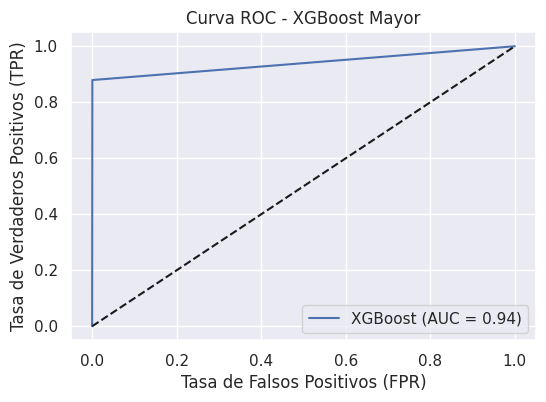

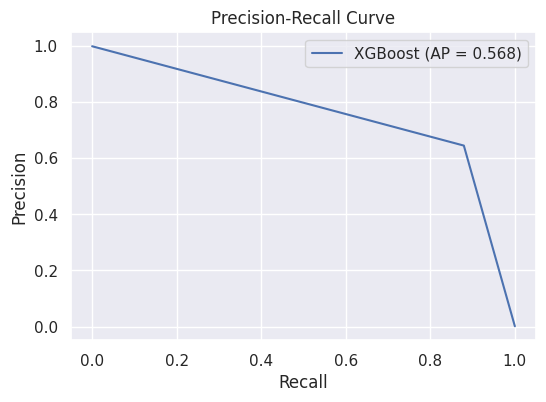

-----------------------------------------
Dataset Mayor
Tamaño train: 128733
Tamaño test: 55172
Porcentaje de positivos: 0.14%
-----------------------------------------
Resultados Mayor
Error_rate  = 0.0006
Precision = [0.00105126 0.64556962 1.        ]
Recall    = [1.         0.87931034 0.        ]
f1_score  = 0.74
roc_auc  = 0.94
auprc  = 0.57
-----------------------------------------


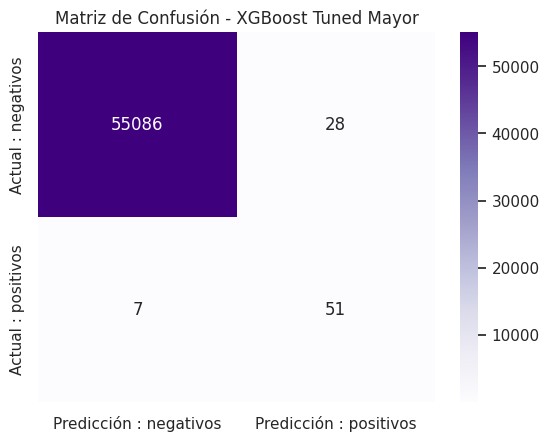

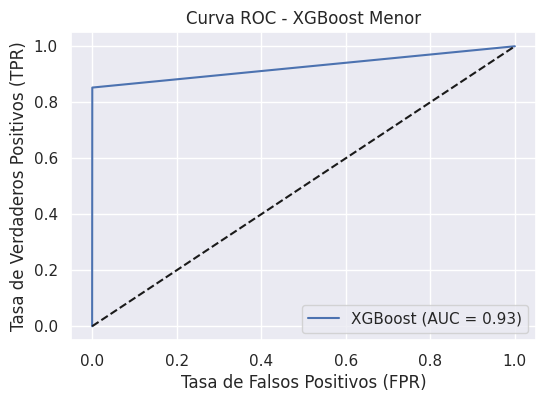

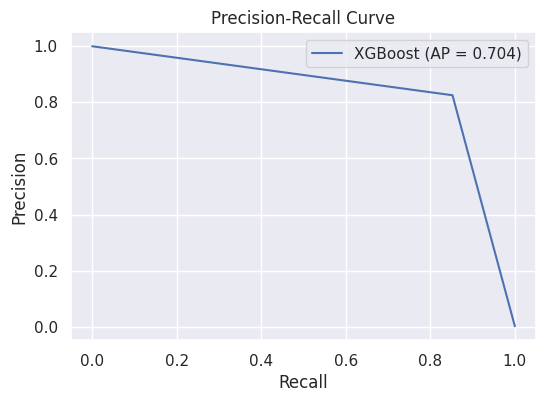

-----------------------------------------
Dataset Menor
Tamaño train: 68609
Tamaño test: 29404
Porcentaje de positivos: 0.22%
-----------------------------------------
Resultados Menor
Error_rate  = 0.0007
Precision = [0.00207455 0.82539683 1.        ]
Recall    = [1.         0.85245902 0.        ]
f1_score  = 0.84
roc_auc  = 0.93
auprc  = 0.70
-----------------------------------------


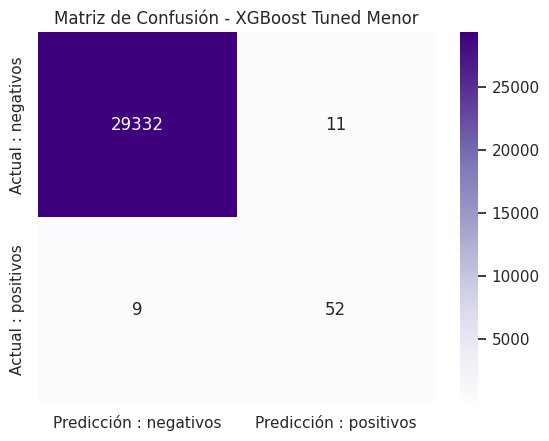

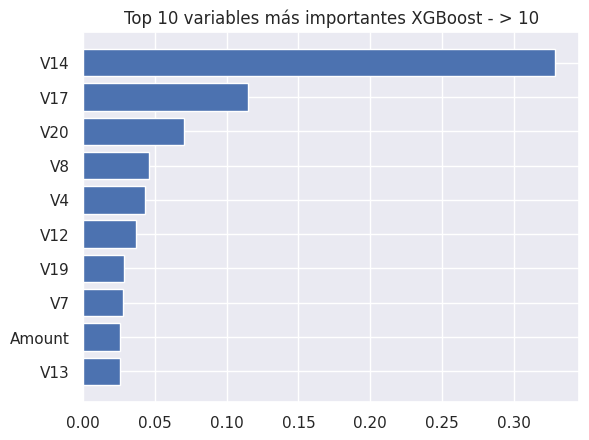

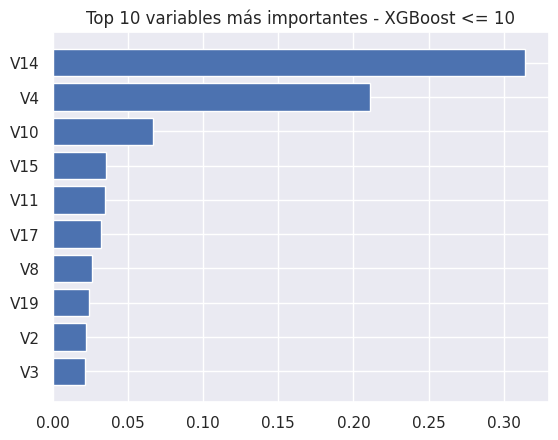

In [ ]:
# Reporte XGBOOST
cm_xgb_tuned_mayor = report(X_train_mayor, y_train_mayor, X_test_mayor, y_test_mayor, model=best_xgb_model_mayor, type="Mayor", model_name="XGBoost")
sns.heatmap(cm_xgb_tuned_mayor, annot=True, cmap="Purples", fmt='d')
plt.title("Matriz de Confusión - XGBoost Tuned " + "Mayor")
plt.show()

cm_xgb_tuned_menor = report(X_train_menor, y_train_menor, X_test_menor, y_test_menor, model=best_xgb_model_menor, type="Menor",model_name="XGBoost")
sns.heatmap(cm_xgb_tuned_menor, annot=True, cmap="Purples", fmt='d')
plt.title("Matriz de Confusión - XGBoost Tuned " + "Menor")
plt.show()

xgb_importances_mayor = best_xgb_model_mayor.feature_importances_
indices = np.argsort(xgb_importances_mayor)[-10:]

plt.figure()
plt.title("Top 10 variables más importantes XGBoost - > 10")
plt.barh(range(len(indices)), xgb_importances_mayor[indices])
plt.yticks(range(len(indices)), X_mayor.columns[indices])
plt.show()

xgb_importances_menor = best_xgb_model_menor.feature_importances_
indices = np.argsort(xgb_importances_menor)[-10:]

plt.figure()
plt.title("Top 10 variables más importantes - XGBoost <= 10")
plt.barh(range(len(indices)), xgb_importances_menor[indices])
plt.yticks(range(len(indices)), X_menor.columns[indices])
plt.show()

# LIGHTGBM Tuned

In [ ]:
%pip install lightgbm
from lightgbm import LGBMClassifier

## Fit del modelo con GridSearch

In [ ]:
# Grid de hiperparámetros
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1],
    'num_leaves': [15, 31],
    'min_child_samples': [10, 20]
}

# Instanciamos el clasificador base
lgbm_mayor = LGBMClassifier(random_state=rnd_state, verbose=-1,scale_pos_weight=ratio_mayor)
lgbm_menor = LGBMClassifier(random_state=rnd_state, verbose=-1,scale_pos_weight=ratio_menor,)

# GridSearchCV
grid_search_mayor = GridSearchCV(
    estimator=lgbm_mayor,
    param_grid=param_grid,
    cv=3,
    scoring='average_precision',
    verbose=1,
    n_jobs=-1

)

grid_search_menor = GridSearchCV(
    estimator=lgbm_menor,
    param_grid=param_grid,
    cv=3,
    scoring='average_precision',
    verbose=1,
    n_jobs=-1
)

# Entrenamos con el conjunto de entrenamiento
grid_search_mayor.fit(X_train_mayor, y_train_mayor)
grid_search_menor.fit(X_train_menor, y_train_menor)

# Mejor modelo encontrado
best_model_mayor = grid_search_mayor.best_estimator_
best_model_menor = grid_search_menor.best_estimator_



Fitting 3 folds for each of 48 candidates, totalling 144 fits
Fitting 3 folds for each of 48 candidates, totalling 144 fits


## Reporte LightGBM

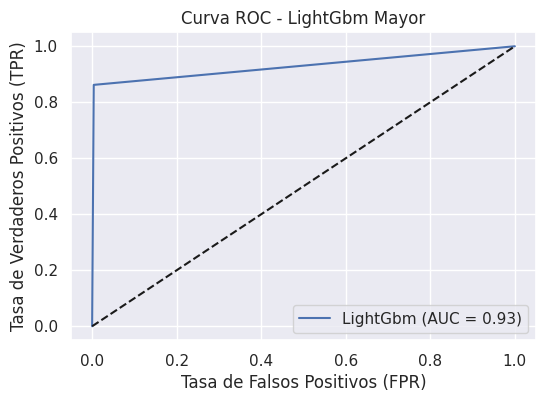

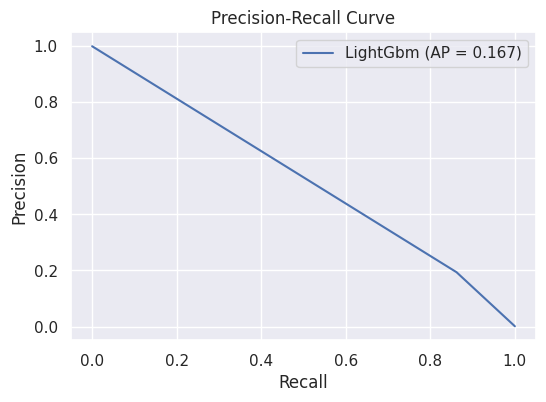

-----------------------------------------
Dataset Mayor
Tamaño train: 128733
Tamaño test: 55172
Porcentaje de positivos: 0.14%
-----------------------------------------
Resultados Mayor
Error_rate  = 0.0039
Precision = [0.00105126 0.19379845 1.        ]
Recall    = [1.         0.86206897 0.        ]
f1_score  = 0.32
roc_auc  = 0.93
auprc  = 0.17
-----------------------------------------


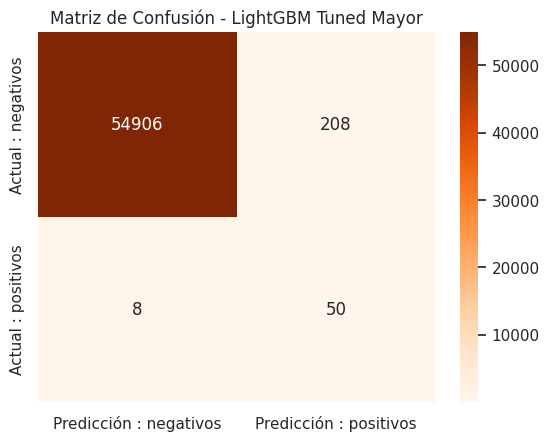

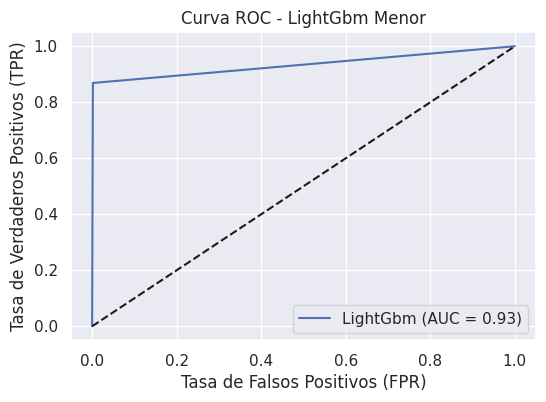

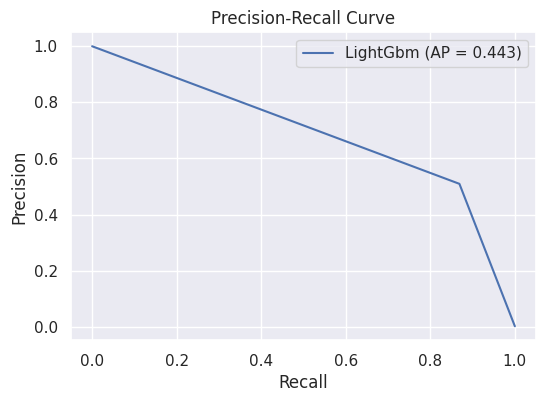

-----------------------------------------
Dataset Menor
Tamaño train: 68609
Tamaño test: 29404
Porcentaje de positivos: 0.22%
-----------------------------------------
Resultados Menor
Error_rate  = 0.002
Precision = [0.00207455 0.50961538 1.        ]
Recall    = [1.         0.86885246 0.        ]
f1_score  = 0.64
roc_auc  = 0.93
auprc  = 0.44
-----------------------------------------


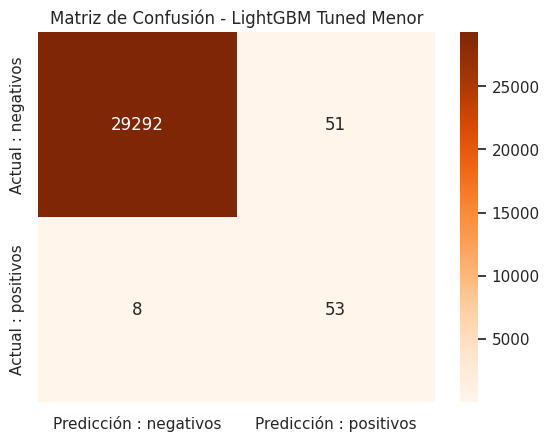

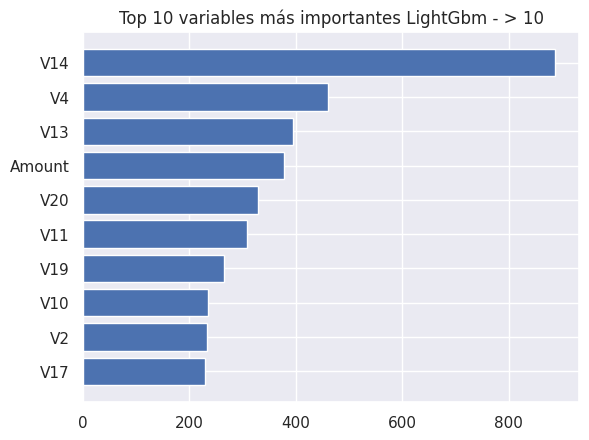

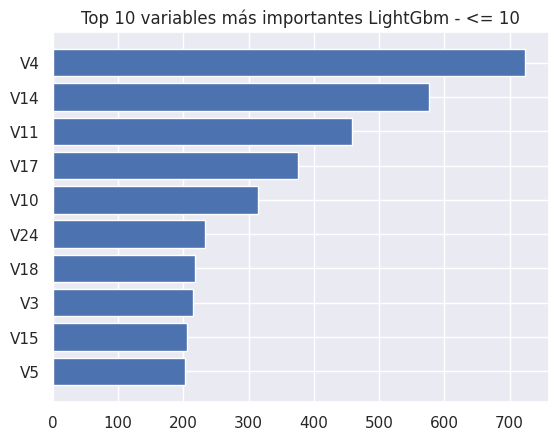

In [ ]:
# Reporte LightGBM
cm_lgbm_tuned_mayor = report(X_train_mayor, y_train_mayor, X_test_mayor, y_test_mayor, model=best_model_mayor, type="Mayor",model_name="LightGbm")
sns.heatmap(cm_lgbm_tuned_mayor, annot=True, cmap="Oranges", fmt='d')
plt.title("Matriz de Confusión - LightGBM Tuned Mayor")
plt.show()

cm_lgbm_tuned_menor = report(X_train_menor, y_train_menor, X_test_menor, y_test_menor, model=best_model_menor, type="Menor",model_name="LightGbm")
sns.heatmap(cm_lgbm_tuned_menor, annot=True, cmap="Oranges", fmt='d')
plt.title("Matriz de Confusión - LightGBM Tuned Menor")
plt.show()

light_importances_mayor = best_model_mayor.feature_importances_
indices = np.argsort(light_importances_mayor)[-10:]

plt.figure()
plt.title("Top 10 variables más importantes LightGbm - > 10")
plt.barh(range(len(indices)), light_importances_mayor[indices])
plt.yticks(range(len(indices)), X_mayor.columns[indices])
plt.show()

light_importances_menor = best_model_menor.feature_importances_
indices = np.argsort(light_importances_menor)[-10:]

plt.figure()
plt.title("Top 10 variables más importantes LightGbm - <= 10")
plt.barh(range(len(indices)), light_importances_menor[indices])
plt.yticks(range(len(indices)), X_menor.columns[indices])
plt.show()

# CATBOOST Tuned

In [ ]:
%pip install catboost
from sklearn.model_selection import GridSearchCV
from catboost import CatBoostClassifier

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.9 MB/s eta 0:00:00


## Fit del modelo con GridSearch

In [ ]:
from sklearn.model_selection import GridSearchCV
from catboost import CatBoostClassifier

# Grid de hiperparámetros
param_grid_catboost = {
    'iterations': [100, 200],
    'depth': [4, 6, 8],
    'learning_rate': [0.01, 0.1],
    'l2_leaf_reg': [1, 3, 5]
}

# Modelo base
cat_model_mayor = CatBoostClassifier(
    random_seed=42,
    verbose=0,
    #cat_features=categorical_columns
    scale_pos_weight=ratio_mayor,
)

# GridSearch
grid_search_catboost_mayor = GridSearchCV(
    estimator=cat_model_mayor,
    param_grid=param_grid_catboost,
    cv=3,
    scoring='average_precision',
    verbose=1,
    n_jobs=-1
)

cat_model_menor = CatBoostClassifier(
    random_seed=42,
    verbose=0,
    #cat_features=categorical_columns
    scale_pos_weight=ratio_menor,
)

# GridSearch
grid_search_catboost_menor = GridSearchCV(
    estimator=cat_model_menor,
    param_grid=param_grid_catboost,
    cv=3,
    scoring='average_precision',
    verbose=1,
    n_jobs=-1
)


# Entrenamiento
grid_search_catboost_mayor.fit(X_train_mayor, y_train_mayor)
grid_search_catboost_menor.fit(X_train_menor, y_train_menor)

# Mejor modelo
best_cat_model_mayor = grid_search_catboost_mayor.best_estimator_
best_cat_model_menor = grid_search_catboost_menor.best_estimator_




Fitting 3 folds for each of 36 candidates, totalling 108 fits
Fitting 3 folds for each of 36 candidates, totalling 108 fits


## Reporte CatBoost

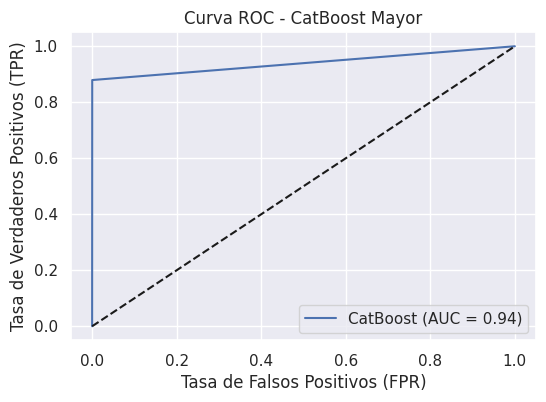

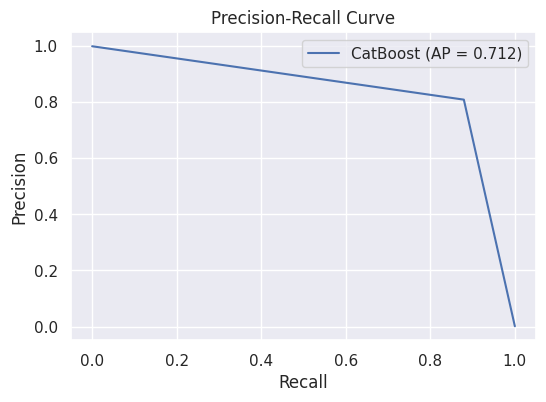

-----------------------------------------
Dataset Mayor
Tamaño train: 128733
Tamaño test: 55172
Porcentaje de positivos: 0.14%
-----------------------------------------
Resultados Mayor
Error_rate  = 0.0003
Precision = [0.00105126 0.80952381 1.        ]
Recall    = [1.         0.87931034 0.        ]
f1_score  = 0.84
roc_auc  = 0.94
auprc  = 0.71
-----------------------------------------


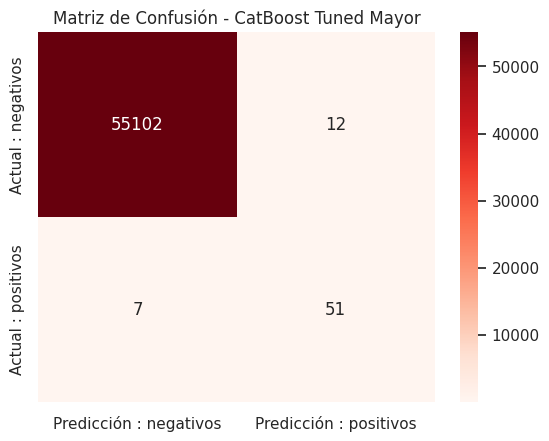

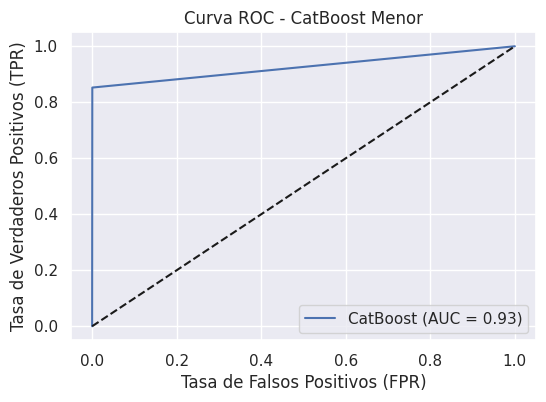

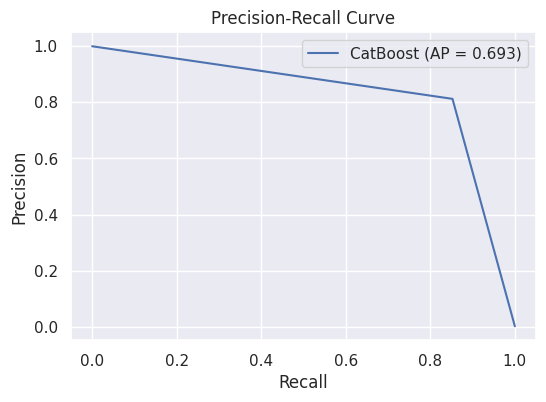

-----------------------------------------
Dataset Menor
Tamaño train: 68609
Tamaño test: 29404
Porcentaje de positivos: 0.22%
-----------------------------------------
Resultados Menor
Error_rate  = 0.0007
Precision = [0.00207455 0.8125     1.        ]
Recall    = [1.         0.85245902 0.        ]
f1_score  = 0.83
roc_auc  = 0.93
auprc  = 0.69
-----------------------------------------


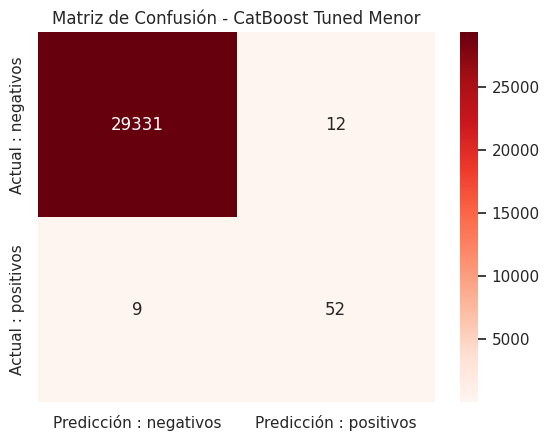

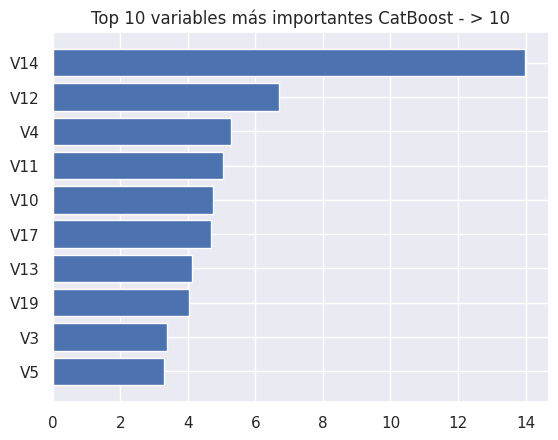

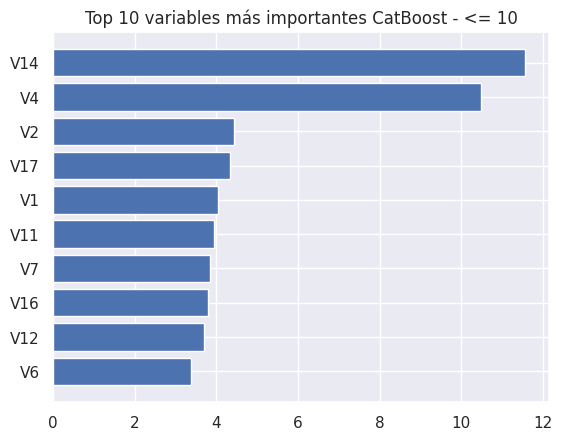

In [ ]:
# Reporte Catboost
cm_catboost_tuned_mayor = report(X_train_mayor, y_train_mayor, X_test_mayor, y_test_mayor, model=best_cat_model_mayor, type="Mayor",model_name="CatBoost")
sns.heatmap(cm_catboost_tuned_mayor, annot=True, cmap="Reds", fmt='d')
plt.title("Matriz de Confusión - CatBoost Tuned Mayor")
plt.show()

cm_catboost_tuned_menor = report(X_train_menor, y_train_menor, X_test_menor, y_test_menor, model=best_cat_model_menor, type="Menor",model_name="CatBoost")
sns.heatmap(cm_catboost_tuned_menor, annot=True, cmap="Reds", fmt='d')
plt.title("Matriz de Confusión - CatBoost Tuned Menor")
plt.show()

cat_importances_mayor = best_cat_model_mayor.feature_importances_
indices = np.argsort(cat_importances_mayor)[-10:]

plt.figure()
plt.title("Top 10 variables más importantes CatBoost - > 10")
plt.barh(range(len(indices)), cat_importances_mayor[indices])
plt.yticks(range(len(indices)), X_mayor.columns[indices])
plt.show()

cat_importances_menor = best_cat_model_menor.feature_importances_
indices = np.argsort(cat_importances_menor)[-10:]

plt.figure()
plt.title("Top 10 variables más importantes CatBoost - <= 10")
plt.barh(range(len(indices)), cat_importances_menor[indices])
plt.yticks(range(len(indices)), X_menor.columns[indices])
plt.show()

# COMPARATIVA FINAL

In [ ]:
def get_model_metrics(y_true, y_pred, model_name):
    return {
        'Modelo': model_name,
        #'Accuracy': float('{0:.2f}'.format(accuracy_score(y_true, y_pred))),
        'Precision': float('{0:.2f}'.format(precision_score(y_true, y_pred))),
        'Recall': float('{0:.2f}'.format(recall_score(y_true, y_pred))),
        'F1-score': float('{0:.2f}'.format(f1_score(y_true, y_pred))),
        'roc_auc' : float('{0:.2f}'.format(roc_auc_score(y_true, y_pred))),
        'auprc' : float('{0:.2f}'.format(average_precision_score(y_true, y_pred)))
    }

In [ ]:
# Predicciones
y_pred_xgb_mayor = best_xgb_model_mayor.predict(X_test_mayor)
y_pred_lgb_mayor = best_model_mayor.predict(X_test_mayor)
y_pred_cat_mayor = best_cat_model_mayor.predict(X_test_mayor)

y_pred_xgb_menor = best_xgb_model_menor.predict(X_test_menor)
y_pred_lgb_menor = best_model_menor.predict(X_test_menor)
y_pred_cat_menor = best_cat_model_menor.predict(X_test_menor)

# Métricas
metrics_xgb_mayor = get_model_metrics(y_test_mayor, y_pred_xgb_mayor, "XGBoost Mayor")
metrics_lgb_mayor = get_model_metrics(y_test_mayor, y_pred_lgb_mayor, "LightGBM Mayor")
metrics_cat_mayor = get_model_metrics(y_test_mayor, y_pred_cat_mayor, "CatBoost Mayor")

metrics_xgb_menor = get_model_metrics(y_test_menor, y_pred_xgb_menor, "XGBoost Menor")
metrics_lgb_menor = get_model_metrics(y_test_menor, y_pred_lgb_menor, "LightGBM Menor")
metrics_cat_menor = get_model_metrics(y_test_menor, y_pred_cat_menor, "CatBoost Menor")

# DataFrame con resultados
df_metrics_mayor = pd.DataFrame([metrics_xgb_mayor, metrics_lgb_mayor, metrics_cat_mayor])
df_metrics_menor = pd.DataFrame([metrics_xgb_menor, metrics_lgb_menor, metrics_cat_menor])


In [ ]:
df_metrics_mayor.sort_values(by=["auprc"], ascending=False)

,Modelo,Precision,Recall,F1-score,roc_auc,auprc
2,CatBoost Mayor,0.81,0.88,0.84,0.94,0.71
0,XGBoost Mayor,0.65,0.88,0.74,0.94,0.57
1,LightGBM Mayor,0.19,0.86,0.32,0.93,0.17


In [ ]:
df_metrics_menor.sort_values(by=["auprc"], ascending=False)

,Modelo,Precision,Recall,F1-score,roc_auc,auprc
0,XGBoost Menor,0.83,0.85,0.84,0.93,0.70
2,CatBoost Menor,0.81,0.85,0.83,0.93,0.69
1,LightGBM Menor,0.51,0.87,0.64,0.93,0.44


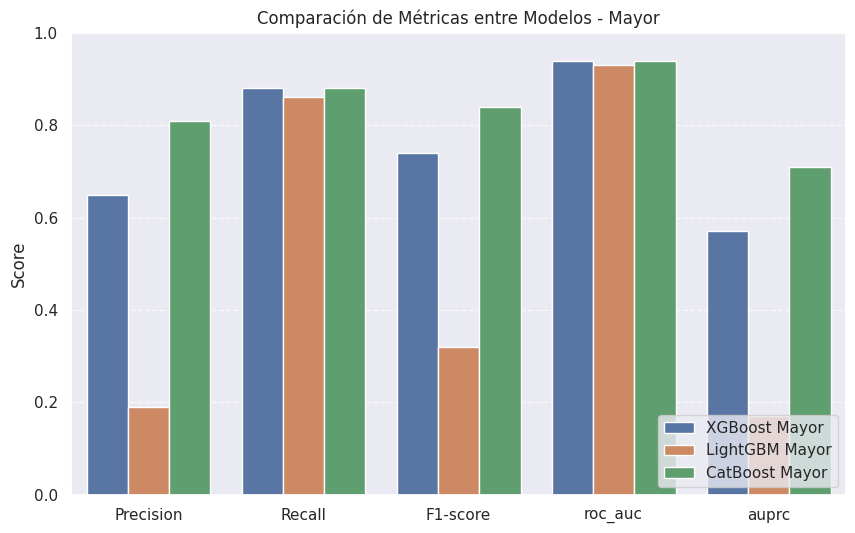

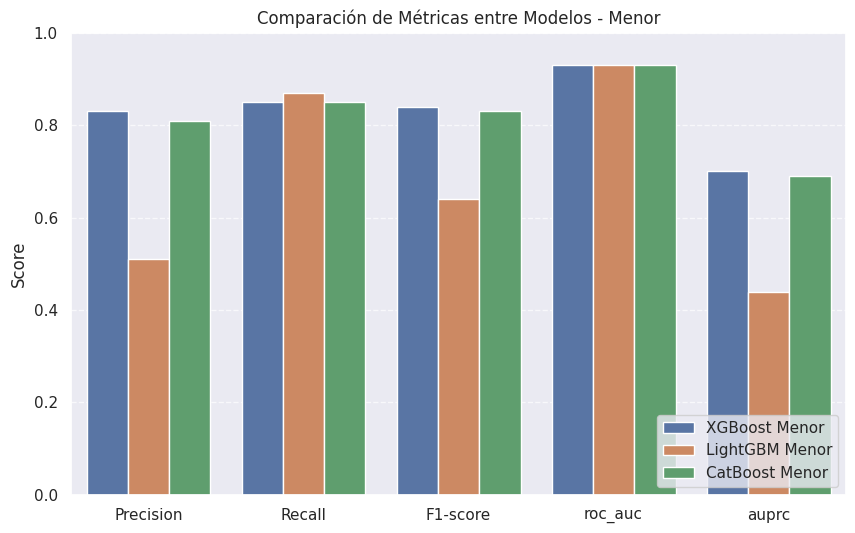

In [ ]:
# Convertimos a formato largo para graficar
df_melted_mayor = df_metrics_mayor.melt(id_vars='Modelo', var_name='Métrica', value_name='Valor')
df_melted_menor = df_metrics_menor.melt(id_vars='Modelo', var_name='Métrica', value_name='Valor')

plt.figure(figsize=(10, 6))
sns.barplot(data=df_melted_mayor, x='Métrica', y='Valor', hue='Modelo')
plt.ylim(0.0, 1)
plt.title('Comparación de Métricas entre Modelos - Mayor')
plt.ylabel('Score')
plt.xlabel('')
plt.legend(loc='lower right')
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.show()

plt.figure(figsize=(10, 6))
sns.barplot(data=df_melted_menor, x='Métrica', y='Valor', hue='Modelo')
plt.ylim(0.0, 1)
plt.title('Comparación de Métricas entre Modelos - Menor')
plt.ylabel('Score')
plt.xlabel('')
plt.legend(loc='lower right')
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.show()
